# Inference-time Scaling via Self-refinement
## Scoring and Iteratively Improving Model Responses

In [1]:
import torch

from mi.lm.inference_scaling import self_refinement_loop
from mi.lm.model_loader import load_model_and_tokenizer

# device = get_device()
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

✓ downloads/qwen3-0.6B-base.pth already up-to-date


In [2]:
from mi.lm.prompts import render_prompt
from mi.lm.generate import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache
)

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)

prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)

 ### Step 1: Understand the problem

The problem states that half the value of \(3x - 9\) is equal to \(x + 37\). We need to find the value of \(x\).

### Step 2: Translate the problem into an equation

Let's translate the given statement into an equation. Half of \(3x - 9\) is equal to \(x + 37\).

\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 3: Solve the equation

To solve for \(x\), we'll first eliminate the fraction by multiplying both sides of the equation by 2:

\[
2 \times \frac{1}{2}(3x - 9) = 2 \times (x + 37)
\]

This simplifies to:

\[
3x - 9 = 2x + 74
\]

### Step 4: Isolate the variable \(x\)

Now, we'll isolate \(x\) by subtracting \(2x\) from both sides of the equation:

\[
3x - 2x - 9 = 74
\]

Simplifying this, we get:

\[
x - 9 = 74
\]

### Step 5: Solve for \(x\)

Next, we'll add 9 to both sides to solve for \(x\):

\[
x - 9 + 9 = 74 + 9
\]

This simplifies to:

\[
x = 83
\]

### Step 6: Verify the solution

To ensure our solution is correct, we'll substitute \(x = 83

In [3]:
torch.manual_seed(3)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 We start with the equation:

\[
\frac{1}{2} \times (3x - 9) = x + 37
\]

Step 1: Multiply both sides of the equation by 2 to eliminate the fraction:

\[
2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
\]

Simplifying both sides:

\[
3x - 9 = 2x + 74
\]

Step 2: Subtract \(2x\) from both sides to get all the \(x\) terms on one side:

\[
3x - 2x - 9 = 74
\]

Simplifying:

\[
x - 9 = 74
\]

Step 3: Add 9 to both sides to isolate \(x\):

\[
x - 9 + 9 = 74 + 9
\]

Simplifying:

\[
x = 83
\]

Final Answer:

\[
\boxed{83}
\]

In [4]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 1419
Response 1 tokens: 534

Response 2 characters: 533
Response 2 tokens: 231


## Scoring LLM Responses with a Rule-based Score
"Better" refers to format and brevity, not correctness

In [5]:
from mi.extraction import extract_final_candidate
import math


def heuristic_score(
        answer,
        prompt=None,
        brevity_bonus=500.0,
        boxed_bonus=2.0,
        extract_bonus=1.0,
        fulltext_bonus=0.0,
):
    score = 0.0

    cand = extract_final_candidate(answer, fallback="none")

    if cand:
        score += boxed_bonus
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(answer, fallback="number_then_full")
            if cand:
                score += fulltext_bonus

    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score

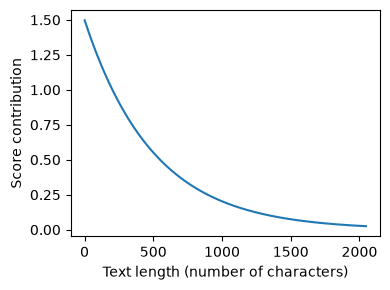

In [6]:
import matplotlib.pyplot as plt
import torch

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len)
    scores = 1.5 * torch.exp(-lengths / brevity_bonus)

    plt.figure(figsize=(4, 3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    plt.show()

plot_brevity_curve(500)


In [7]:
print(round(heuristic_score(response_1), 3))

2.088


In [8]:
print(round(heuristic_score(response_2), 3))

2.517


As a practical rule of thumb, increase the extraction-related bonuses if the scorer too often prefers answers whose final result is hard to parse. Increase the brevity pressure if the scorer keeps favoring long, rambling answers that do not improve the final result. On the other hand, if the scorer starts preferring overly short but incomplete answers, reduce the brevity penalty or increase the reward for clearly extractable final answers. Thinking about these tradeoffs is often more useful than focusing on the exact numeric values in isolation.

Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) (Function). Kindle Edition.

## Token Probability Scores
next-token probabilities, per-token probabilities, sequence likelihoods, or, more loosely, token-level likelihoods. They represent the probability that the model assigns to each possible next token, expressed as a normalized (softmax) distribution over the vocabulary.

Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) (Function). Kindle Edition.

This is a calculation of a model's internal likelihood, not a probability of correctness.

In [9]:
from mi.lm.scoring import calc_next_token_probas
torch.set_printoptions(precision=4, sci_mode=True)
calc_next_token_probas(
    model, tokenizer, device=device,
    prompt="The capital of Germany is Berlin"
)

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 1.6895e-01],
       dtype=torch.bfloat16)
Joint probability: tensor(5.9372e-08, dtype=torch.bfloat16)


(tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 1.6895e-01],
        dtype=torch.bfloat16),
 tensor(5.9372e-08, dtype=torch.bfloat16))

In [10]:
calc_next_token_probas(
    model, tokenizer, device=device,
    prompt="The capital of Germany is Bridge"
)

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 2.9802e-07],
       dtype=torch.bfloat16)
Joint probability: tensor(1.0481e-13, dtype=torch.bfloat16)


(tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 2.9802e-07],
        dtype=torch.bfloat16),
 tensor(1.0481e-13, dtype=torch.bfloat16))

## Log Probabilities
Apply a logarithmic scaling transformation to probabilities to avoid numerical stability issues with increasingly small numbers.

In [11]:
torch.set_printoptions(precision=4, sci_mode=False)
logits = torch.linspace(-2, 2, steps=7)
probas = torch.softmax(logits, dim=-1)
print(probas)

tensor([0.0090, 0.0175, 0.0341, 0.0665, 0.1295, 0.2522, 0.4912])


In [12]:
print(torch.log(probas))

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [13]:
log_probas = torch.log_softmax(logits, dim=-1)
print(log_probas)

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [14]:
from mi.lm.scoring import calc_next_token_logprobas

calc_next_token_logprobas(
    model, tokenizer, device=device,
    prompt="The capital of Germany is Berlin"
)

Next token log-probabilities: tensor([-9.6875, -0.7695, -4.0938, -0.3008, -1.7812], dtype=torch.bfloat16)
Joint log-probability: tensor(-16.6250, dtype=torch.bfloat16)


(tensor([-9.6875, -0.7695, -4.0938, -0.3008, -1.7812], dtype=torch.bfloat16),
 tensor(-16.6250, dtype=torch.bfloat16))

In [15]:
calc_next_token_logprobas(
    model, tokenizer, device=device,
    prompt="The capital of Germany is Bridge"
)

Next token log-probabilities: tensor([ -9.6875,  -0.7695,  -4.0938,  -0.3008, -15.0000],
       dtype=torch.bfloat16)
Joint log-probability: tensor(-29.8750, dtype=torch.bfloat16)


(tensor([ -9.6875,  -0.7695,  -4.0938,  -0.3008, -15.0000],
        dtype=torch.bfloat16),
 tensor(-29.8750, dtype=torch.bfloat16))

## Scoring Model Confidence

In [16]:
example_prompt = "What is the capital of Germany?"
example_answer = " The capital of Germany is Berlin."

next_token_logprobas, sum_next_token_logprobas = calc_next_token_logprobas(
    model, tokenizer, device=device,
    prompt=example_prompt + example_answer,
    show=False
)

print(f"Next token logprobas: {next_token_logprobas}")
print(f"Joint log probas: {sum_next_token_logprobas}")

Next token logprobas: tensor([-0.4512, -0.3418, -8.3125, -0.3906, -3.8125, -3.0469, -1.1719,  0.0000,
        -0.0155,  0.0000, -0.0078, -0.0752, -0.1582], dtype=torch.bfloat16)
Joint log probas: -17.75


In [17]:
print(len(tokenizer.encode(example_answer)))

7


In [18]:
last_7 = next_token_logprobas[-7:]
print(last_7)
print(torch.mean(last_7))

tensor([-1.1719,  0.0000, -0.0155,  0.0000, -0.0078, -0.0752, -0.1582],
       dtype=torch.bfloat16)
tensor(-0.2041, dtype=torch.bfloat16)


In [19]:
from mi.lm.scoring import avg_logprob_answer

score_1 = avg_logprob_answer(
    model, tokenizer, device=device,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Berlin."
)
print(score_1)

tensor(-0.2041, dtype=torch.bfloat16)


In [20]:
score_2 = avg_logprob_answer(
    model, tokenizer, device=device,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Bridge."
)
print(score_2)

tensor(-3.8906, dtype=torch.bfloat16)


### Exercises
#### Exercise 5.3: Using the logprob scorer as a tiebreaker in self-consistency
Using the logprob scorer instead of the heuristic scorer in exercise 5.1, extend the self-consistency implementation (self_consistency_vote) from the previous chapter (listing 4.17) so it can handle ties among candidate answers. Then run the two implementations on a subset of the MATH-500 dataset to see which tiebreaking method performs better.

#### Exercise 5.4: Using the logprob scorer in a best-of-N setup
Extend the self-consistency implementation so that the final answer is chosen using the logprob scorer (avg_logprob_answer) rather than the heuristic scorer or majority voting, as in exercise 5.2. Then run the different implementations on a subset of the MATH-500 dataset to see which tiebreaking method performs better. Tip: You don’t need to modify the self_consistency_vote function itself to apply the tiebreaking. You can apply tiebreaking to the results dictionary returned by self_consistency_vote, which is used inside the evaluate_math500_stream function from listing 3.15.

## Self-refinement Through Iterative Feedback

In [21]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

torch.manual_seed(123)
initial_response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device=device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 \boxed{18}

To solve for \( x \) in the equation:

\[
\frac{1}{2} (3x - 9) = x + 37
\]

**Step 1: Eliminate the fraction by multiplying both sides by 2.**

\[
2 \times \frac{1}{2} (3x - 9) = 2 \times (x + 37)
\]

\[
3x - 9 = 2x + 74
\]

**Step 2: Subtract \( 2x \) from both sides to gather like terms.**

\[
3x - 2x - 9 = 74
\]

\[
x - 9 = 74
\]

**Step 3: Add 9 to both sides to solve for \( x \).**

\[
x = 74 + 9
\]

\[
x = 83
\]

However, let's double-check the steps to ensure accuracy.

**Revisiting Step 2:**

\[
3x - 9 = 2x + 74
\]

Subtract \( 2x \) from both sides:

\[
3x - 2x - 9 = 74
\]

\[
x - 9 = 74
\]

Add 9 to both sides:

\[
x = 83
\]

But let's verify this solution by substituting \( x = 83 \) back into the original equation.

**Original Equation:**

\[
\frac{1}{2} (3x - 9) = x + 37
\]

Substitute \( x = 83 \):

\[
\frac{1}{2} (3 \times 83 - 9) = 83 + 37
\]

\[
\frac{1}{2} (249 - 9) = 120
\]

\[
\frac{1}{2} \times 240 = 120
\]

\[
120 = 120
\]

The equation holds true, co

In [22]:
from mi.lm.prompts import make_critique_prompt


critique_prompt = make_critique_prompt(raw_prompt, initial_response)
torch.manual_seed(123)
critique = generate_text_stream_concat_flex(
    model, tokenizer, critique_prompt, device=device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 The solution provided is correct, but the steps are missing some intermediate calculations. The plan should be concise, avoiding unnecessary steps and ensuring the problem is fully resolved.

Plan:  
1. Start by eliminating the fraction: \( 3x - 9 = 2x + 74 \).  
2. Subtract \( 2x \) from both sides: \( x - 9 = 74 \).  
3. Add 9 to both sides: \( x = 83 \).  
This plan ensures clarity and completeness, providing a clear path to solving the equation.

In [23]:
from mi.lm.prompts import make_refine_prompt

refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)
torch.manual_seed(123)
revised_answer = generate_text_stream_concat_flex(
    model, tokenizer, refine_prompt, device=device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

  
\boxed{83}

## Self-refinement Loop

In [24]:
from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device,
)

In [25]:
from mi.lm.inference_scaling import self_refinement_loop

torch.manual_seed(1)

results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: 10
Revised: 83
Score before: -0.855
Score after: -0.226

[Refinement 2/2]
Current: 83
Revised: 83
Score before: -0.226
Score after: -1.320



**Exercise 5.5: Using the heuristic score for self-refinement**

Run self_refinement_loop using the heuristic_score function, which we defined in listing 5.3.